# ETL - Extract, Transform, Load

In [105]:
import pandas as pd

url_1k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/1k.csv"
url_2k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/2k.csv"
url_4k7 = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/4k7.csv"

# 1000 Ω load
load_1k = pd.read_csv(url_1k, skiprows=17, header=None, usecols=[0, 1, 2])
load_1k.columns = ["time", "dac", "shunt"]
load_1k = load_1k.astype(float)

# 2000 Ω load
load_2k = pd.read_csv(url_2k, skiprows=17, header=None, usecols=[0, 1, 2])
load_2k.columns = ["time", "dac", "shunt"]
load_2k = load_2k.astype(float)

# 4700 Ω load
load_4k7 = pd.read_csv(url_4k7, skiprows=17, header=None, usecols=[0, 1, 2])
load_4k7.columns = ["time", "dac", "shunt"]
load_4k7 = load_4k7.astype(float)

<Axes: xlabel='time'>

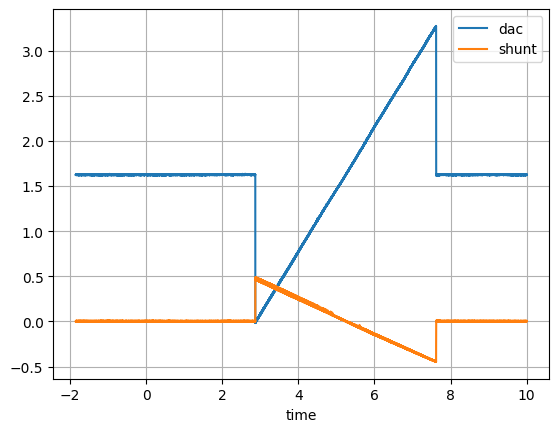

In [106]:
load_1k.plot(x="time", y=["dac", "shunt"], grid=True)

In [107]:
def extract_ramp_region(df, column="dac", step_threshold=0.5):
    data = df.copy()

    diff = data[column].diff().abs()

    transition_points = diff[diff > step_threshold].index

    if len(transition_points) < 2:
        raise ValueError("Could not detect ramp start and end transitions.")

    start = transition_points[0]
    end = transition_points[-1] - 1

    return data.loc[start:end].copy()

In [108]:
load_1k = extract_ramp_region(load_1k, column="dac")
load_2k = extract_ramp_region(load_2k, column="dac")
load_4k7 = extract_ramp_region(load_4k7, column="dac")

<Axes: title={'center': 'Current [mA]'}, xlabel='time'>

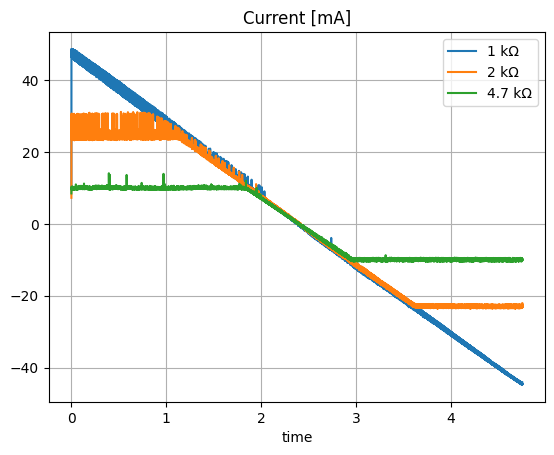

In [109]:
shunt_resistance = 10  # Ω
load_1k["current"] = (load_1k["shunt"] / shunt_resistance) * 1000
load_2k["current"] = (load_2k["shunt"] / shunt_resistance) * 1000
load_4k7["current"] = (load_4k7["shunt"] / shunt_resistance) * 1000

load_1k["time"] = load_1k["time"] - load_1k["time"].iloc[0]
load_2k["time"] = load_2k["time"] - load_2k["time"].iloc[0]
load_4k7["time"] = load_4k7["time"] - load_4k7["time"].iloc[0]

ax = load_1k.plot(x="time", y="current", grid=True, title="Current [mA]", label="1 kΩ")

load_2k.plot(x="time", y="current", ax=ax, label="2 kΩ", grid=True)

load_4k7.plot(x="time", y="current", ax=ax, label="4.7 kΩ", grid=True)

# EDA - Exploratory Data Analysis



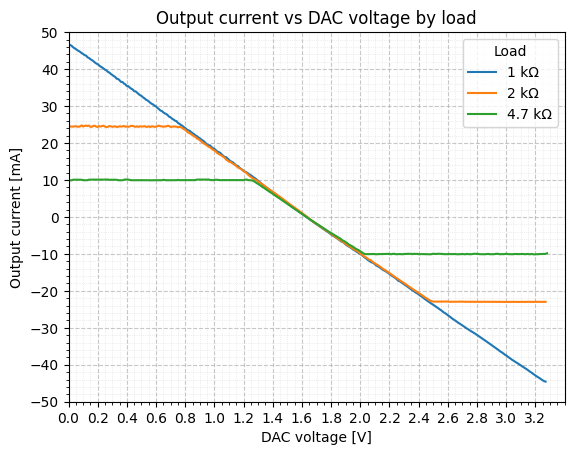

In [110]:
import numpy as np

dac_step = 0.01

load_1k_cmp = load_1k.copy()
load_2k_cmp = load_2k.copy()
load_4k7_cmp = load_4k7.copy()

load_1k_cmp["load"] = "1 kΩ"
load_2k_cmp["load"] = "2 kΩ"
load_4k7_cmp["load"] = "4.7 kΩ"

all_data = pd.concat([load_1k_cmp, load_2k_cmp, load_4k7_cmp], ignore_index=True)

# all_data["dac_bin"] = ( (all_data["dac"] / dac_step).round() * dac_step)
all_data["dac_bin"] = np.floor(all_data["dac"] / dac_step) * dac_step

comparison = all_data.pivot_table(index="dac_bin", columns="load", values="current", aggfunc="mean")

# =========================================================
# Plot
# =========================================================

ax = comparison.plot()

# =========================================================
# X axis
# =========================================================

ax.set_xlim(0, 3.4)

ax.set_xticks(np.arange(0, 3.4, 0.2))

# =========================================================
# Y axis
# =========================================================

ax.set_ylim(-50, 50)

ax.set_yticks(range(-50, 51, 10))

# =========================================================
# Grid
# =========================================================

ax.grid(True, which="major", linestyle="--", alpha=0.7)

# Optional minor grid
ax.minorticks_on()

ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)

# =========================================================
# Labels and title
# =========================================================

ax.set_xlabel("DAC voltage [V]")

ax.set_ylabel("Output current [mA]")

ax.set_title("Output current vs DAC voltage by load")

# =========================================================
# Legend
# =========================================================

ax.legend(title="Load")

In [111]:
comparison["max_current"] = comparison[["1 kΩ", "2 kΩ", "4.7 kΩ"]].max(axis=1)
comparison["min_current"] = comparison[["1 kΩ", "2 kΩ", "4.7 kΩ"]].min(axis=1)

comparison["current_spread"] = comparison["max_current"] - comparison["min_current"]

comparison[["1 kΩ", "2 kΩ", "4.7 kΩ", "current_spread"]].head()

load,1 kΩ,2 kΩ,4.7 kΩ,current_spread
dac_bin,,,,
-0.03,NaN,24.277455,9.840365,14.437091
-0.02,46.937600,24.329558,9.916794,37.020805
-0.01,47.130724,24.466085,9.919587,37.211137
0.00,46.798496,24.647256,9.930252,36.868244
0.01,46.523013,24.434646,9.930973,36.592040


In [112]:
comparison["current_spread"].describe()

count    332.000000
mean      14.325951
std       11.811945
min        0.000000
25%        1.726020
50%       13.248515
75%       24.667239
max       37.211137
Name: current_spread, dtype: float64

<Axes: title={'center': 'Current spread between loads'}, xlabel='dac_bin'>

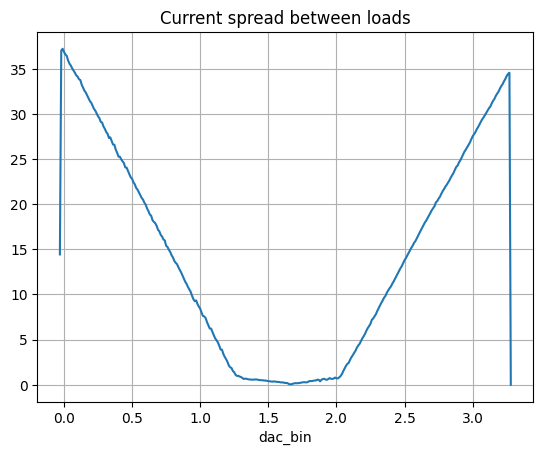

In [113]:
comparison["current_spread"].plot(grid=True, title="Current spread between loads")

In [114]:
load_1k["current"].describe()

count    59409.000000
mean         0.790939
std         26.656711
min        -44.846875
25%        -22.371875
50%          0.320312
75%         23.835938
max         48.792187
Name: current, dtype: float64